## LTM - implementation

### Chatbot Reading Existing Memories

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob 
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Suman"})
store.put(user_details, "profile_2", {"data": "Profession: Solution consultant. also loves teaching"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [ ]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Suman...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In Python apps..." 
say "Since your project is built with Python..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

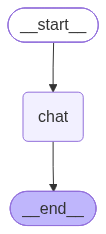

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [7]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Sure, Suman! Generative AI, or Gen AI, is a type of artificial intelligence that can create new content rather than just analyze or process existing data. This includes generating text, images, music, or even code based on the patterns it learned from a large set of examples.

For example, if you were to ask a generative AI model to write a short story or generate code snippets in Python, it would use its training to come up with original content that resembles what it's learned.

Would you like to delve deeper into how it can be applied in your work as a solution consultant, or do you have another aspect of Gen AI in mind? Here are some questions you might consider:

1. Are you interested in specific applications of Gen AI in your projects?
2. Would you like to see a Python example of generating content with an AI model?
3. How do you think Gen AI could enhance your teaching methods?


### Chatbot Creating New Memories

In [8]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [9]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [10]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [11]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [12]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [13]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

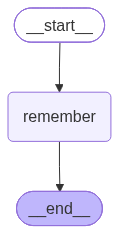

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [15]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Suman"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [16]:
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI and give workshop"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [17]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [18]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Suman.
User teaches AI.
User gives workshops.
User's favorite programming language is Python.


### Chatbot Creating New Memories(without Duplication)

In [19]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [20]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [21]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [22]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [23]:

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [24]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [25]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [26]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [27]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [28]:
config = {"configurable": {"user_id": "u1"}}

In [29]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Suman"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [30]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [31]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Suman.
Suman likes Python for programming.


## merged workflow

In [32]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [33]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [34]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Suman...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [35]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [36]:

class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [37]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [38]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [39]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [40]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [41]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [42]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

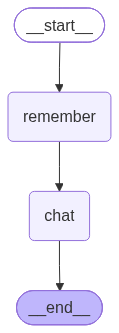

In [43]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [44]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [45]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Suman"}]}, config)
result['messages'][-1].content

"Hi Suman! It's great to meet you. How can I assist you today?"

In [46]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Suman.


In [47]:
result = graph.invoke({"messages": [{"role": "user", "content": "I teach AI and give workshop"}]}, config)
print(result['messages'][-1].content)

That's great to hear, Suman! Teaching AI and conducting workshops is such an impactful way to share knowledge and inspire others. What topics in AI do you usually cover in your workshops? Are there any specific projects you're currently working on or techniques you're excited to share with your students?


In [48]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Suman.
Suman teaches AI.
Suman gives workshops.


In [49]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Suman! Generative AI, often referred to as GenAI, is a type of artificial intelligence that can create new content. This includes things like text, images, music, and even video. It works by learning from existing data and then using that knowledge to generate unique outputs.

For example, a text-based GenAI might analyze thousands of books and articles to learn how humans write, and then it can produce its own stories or articles based on that understanding. In a workshop setting, you might explain it as a kind of digital creativity, where AI serves as a collaborator or assistant in generating ideas and content.

Would you like to dive deeper into a specific aspect of GenAI, perhaps how it can be used in teaching or workshops? 

Here are a few questions you might consider:
1. Are there specific applications of GenAI that you find particularly interesting for your workshops?
2. Do you want to explore the ethical implications of using GenAI in education?
3. Would you like tips on 

In [50]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Suman.
Suman teaches AI.
Suman gives workshops.
